In [1]:
## Import modules
import xarray as xr
import numpy as np
import pandas as pd

#import ThetaoSectors as TS
#import BasalMelt as BM
#import FreshWaterForcing as FWF
#from config import gamma, ism, bm, fwf_distribution, running_mean_period, FWF_total_yearmin


In [2]:

# Constants
spy               = 3600*24*365   # [s yr^-1]
kg_per_Gt         = 1e12         # [kg] to [Gt]

ini_data_dir2='/ec/res4/hpcperm/nm6/ece3data/'
ini_data_dir='/ec/res4/hpcperm/nk0j/ece3data_fwf/'

########################## File definition #########################
## Paths
path_input = f'{ini_data_dir2}/nemo/fwf/interactive/input/'
file_area = f'{path_input}/areacello_Ofx_EC-Earth3_historical_r1i1p1f1_gn.nc'
file_basal_melt_mask = f'{ini_data_dir}/masks/basal_melt_mask_LARMIP_ORCA1.nc'
file_calving_mask = f'{ini_data_dir}/masks/calving_mask_LARMIP_ORCA1.nc'
file_bm_depth1 = f'{path_input}/basal_melt_depth1.nc' #shallowest depth
file_bm_depth2 =f'{path_input}/basal_melt_depth2.nc' # deepest depth



In [3]:
##################### Distribution over ocean grid ######################

##
# Read distribution mask from file
#with open(file_distribution_area) as f:
#    distribution_area = f.read()
#distribution_mask = xr.open_dataset(file_distribution_mask)
basal_melt_mask = xr.open_dataset(file_basal_melt_mask)
calving_mask = xr.open_dataset(file_calving_mask)
ds_depth=xr.open_dataset(file_bm_depth2)-xr.open_dataset(file_bm_depth1)


In [4]:
basal_melt_mask

<xarray.Dataset>
Dimensions:          (y: 292, x: 362)
Coordinates:
    lat              (y, x) float32 ...
    lon              (y, x) float32 ...
Dimensions without coordinates: y, x
Data variables:
    basal_melt_mask  (y, x) float64 ...

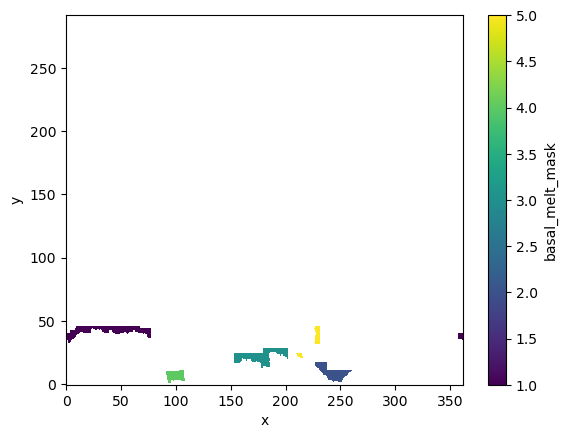

In [5]:
basal_melt_mask['basal_melt_mask'].plot.pcolormesh()

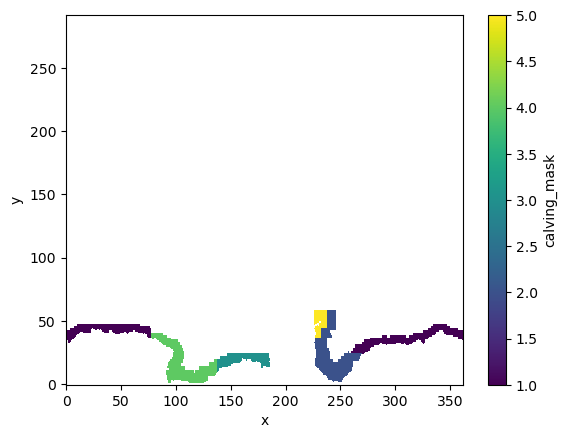

In [6]:
calving_mask['calving_mask'].plot.pcolormesh()

In [7]:
## Open areacello dataarray and compute area corresponding with  distribution mask
ds_area = xr.open_dataset(file_area)
ds_area


<xarray.Dataset>
Dimensions:             (j: 292, i: 362, vertices: 4)
Coordinates:
  * j                   (j) int32 1 2 3 4 5 6 7 ... 286 287 288 289 290 291 292
  * i                   (i) int32 1 2 3 4 5 6 7 ... 356 357 358 359 360 361 362
    latitude            (j, i) float64 ...
    longitude           (j, i) float64 ...
Dimensions without coordinates: vertices
Data variables:
    vertices_latitude   (j, i, vertices) float64 ...
    vertices_longitude  (j, i, vertices) float64 ...
    areacello           (j, i) float32 ...
Attributes: (12/47)
    Conventions:                        CF-1.7 CMIP-6.2
    activity_id:                        CMIP
    branch_method:                      standard
    branch_time:                        0.0
    comment:                            Production: Thomas Reerink at KNMI
    contact:                            cmip6-data@ec-earth.org
    ...                                 ...
    cmor_version:                       3.5.0
    tracking_id:                        hdl:21.14100/d40e307d-1ea0-4c90-a6e3-...
    branch_time_in_child:               0.0D
    branch_time_in_parent:              149749.0D
    history:                            2019-09-26T10:31:03Z ; CMOR rewrote d...
    latest_applied_cmor_fixer_version:  v3.0

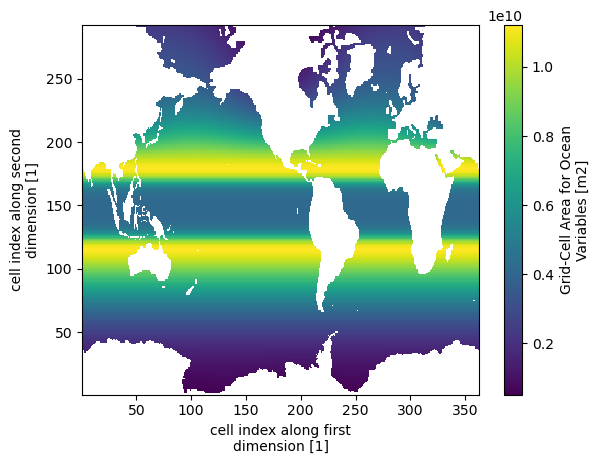

In [8]:
#distribution_area = ds_area.areacello.where(distribution_mask.friver).sum('j').sum('i').values
#print('Freshwater distribution area: ', distribution_area, 'm^2')
ds_area['areacello'].plot.pcolormesh()

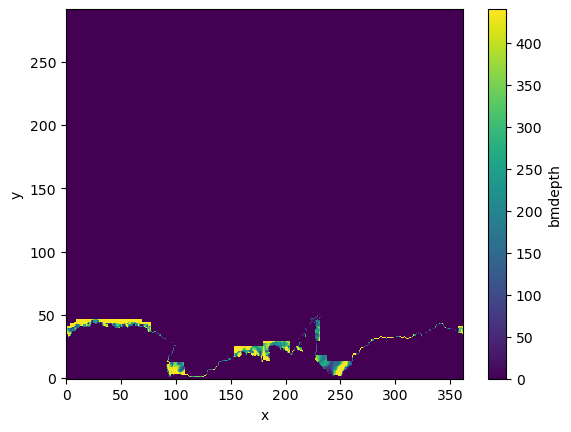

In [9]:
ds_depth['bmdepth'].plot.pcolormesh()

In [10]:
basal_melt_mask = basal_melt_mask.rename({'lon':'longitude','lat':'latitude','y':'j','x':'i'})
basal_melt_mask

<xarray.Dataset>
Dimensions:          (j: 292, i: 362)
Coordinates:
    latitude         (j, i) float32 ...
    longitude        (j, i) float32 ...
Dimensions without coordinates: j, i
Data variables:
    basal_melt_mask  (j, i) float64 nan nan nan nan nan ... nan nan nan nan nan

In [11]:
calving_mask = calving_mask.rename({'lon':'longitude','lat':'latitude','y':'j','x':'i'})
calving_mask

<xarray.Dataset>
Dimensions:       (j: 292, i: 362)
Coordinates:
    latitude      (j, i) float32 ...
    longitude     (j, i) float32 ...
Dimensions without coordinates: j, i
Data variables:
    calving_mask  (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan

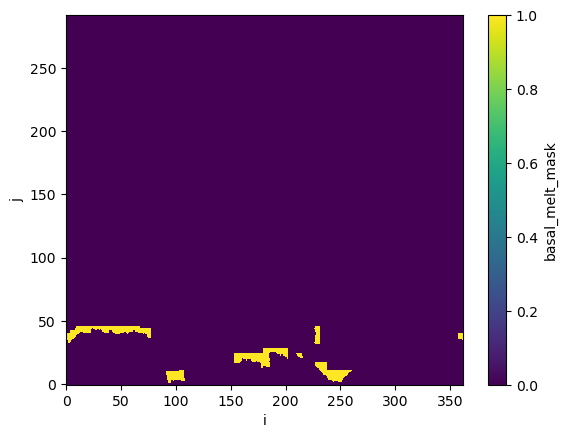

In [12]:
mask_new = basal_melt_mask['basal_melt_mask']>0
mask_new.plot.pcolormesh()

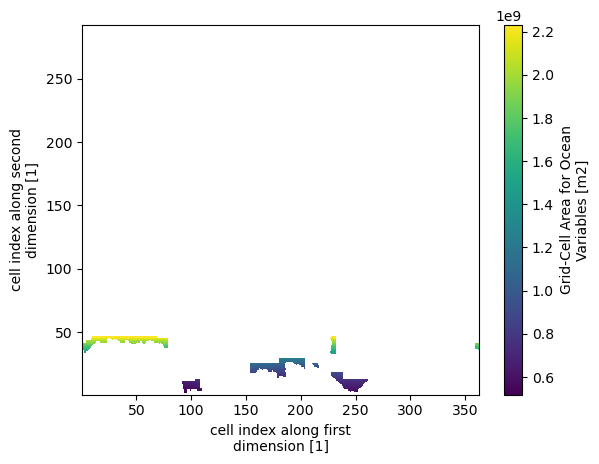

In [13]:
dr_basal_melt_area = ds_area['areacello'].where(mask_new)
dr_basal_melt_area.plot.pcolormesh()


In [14]:
dr_basal_melt_area

<xarray.DataArray 'areacello' (j: 292, i: 362)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * j         (j) int32 1 2 3 4 5 6 7 8 9 ... 285 286 287 288 289 290 291 292
  * i         (i) int32 1 2 3 4 5 6 7 8 9 ... 355 356 357 358 359 360 361 362
    latitude  (j, i) float64 -78.39 -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
Attributes:
    standard_name:  cell_area
    long_name:      Grid-Cell Area for Ocean Variables
    comment:        Horizontal area of ocean grid cells
    units:          m2
    original_name:  areacello
    cell_methods:   area: sum

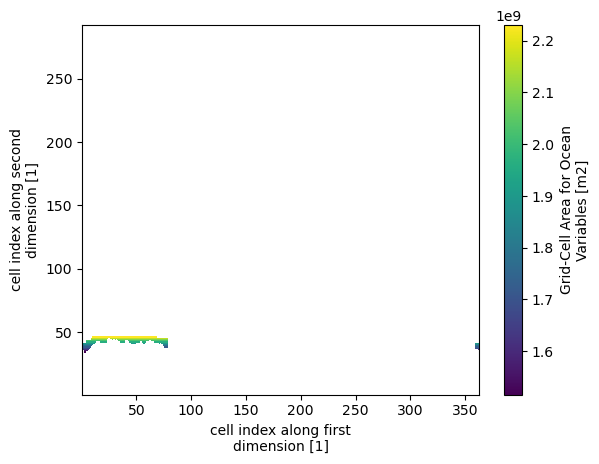

In [15]:
dr_basal_melt_area1 = dr_basal_melt_area.where(basal_melt_mask['basal_melt_mask']==1)
dr_basal_melt_area1.plot.pcolormesh()


In [16]:
area1 = dr_basal_melt_area1.sum(['j','i']).values
area1


array(7.9903215e+11, dtype=float32)

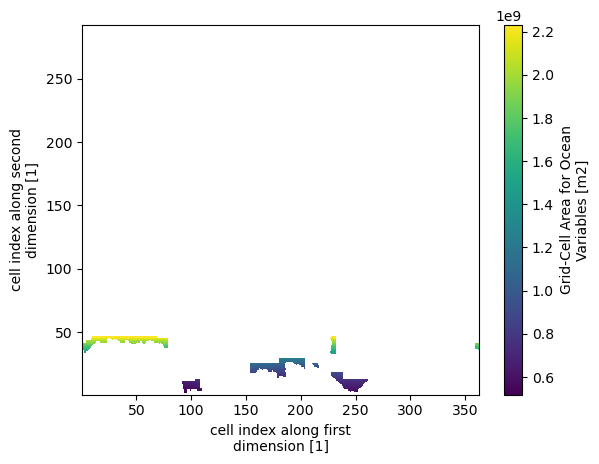

In [17]:
larmip_basal_melt_mask=ds_area['areacello'].where(basal_melt_mask['basal_melt_mask']>0)
larmip_basal_melt_mask.plot.pcolormesh()

In [18]:
fwf_distribution='uniform'
# Distribution options
if fwf_distribution=='uniform':
    basal_melt_area = ds_area.areacello.where(basal_melt_mask.basal_melt_mask>0).sum('j').sum('i').values
    print('Basal melt area: ', basal_melt_area/1e12, '10^12 m^2')
    calving_area = ds_area.areacello.where(calving_mask.calving_mask>0).sum('j').sum('i').values
    print('Calving area: ', calving_area/1e12, '10^12 m^2')
    basal_melt_volume = np.nansum(ds_area.areacello.where(basal_melt_mask.basal_melt_mask).values*ds_depth.bmdepth.values)
    print('Basal melt volume: ', basal_melt_volume/1e12, '10^12 m^3')


Basal melt area:  1.56083945472 10^12 m^2
Calving area:  5.145352470528 10^12 m^2
Basal melt volume:  648.583799035842 10^12 m^3


In [19]:

## Dictionary for finding response functions related to the ocean sectors
sectors=['eais','wedd','amun','ross','apen']
sector_dict = {'eais': 1,
          'wedd': 2,
          'amun': 3,
          'ross': 4,
          'apen': 5}


In [20]:

fwf_distribution='larmip'
sector=1

if fwf_distribution=='larmip':
    basal_melt_mask_sector = basal_melt_mask.basal_melt_mask==sector
    basal_melt_area_sector = ds_area.areacello.where(basal_melt_mask_sector).sum('j').sum('i').values
    print('Basal melt area: ', basal_melt_area_sector/1e12, '10^12 m^2')

    calving_mask_sector = calving_mask.calving_mask==sector
    calving_area_sector = ds_area.areacello.where(calving_mask_sector).sum('j').sum('i').values
    print('Calving area: ', calving_area_sector/1e12, '10^12 m^2')

    basal_melt_volume_sector = np.nansum(ds_area.areacello.where(basal_melt_mask_sector).values*ds_depth.bmdepth.values)
    print('Basal melt volume: ', basal_melt_volume_sector/1e12, '10^12 m^3')
    


Basal melt area:  0.799032213504 10^12 m^2
Calving area:  2.27500490752 10^12 m^2
Basal melt volume:  255.994719070423 10^12 m^3


In [21]:
ds_area.areacello.where(calving_mask.calving_mask==sector_dict['eais']).sum('j').sum('i').values

array(2.275005e+12, dtype=float32)

In [22]:
df_fwf_geom = pd.DataFrame(index=sectors+['sum'],columns=['calving area','basal melt area','basal melt volume'])
df_fwf_geom


,calving area,basal melt area,basal melt volume
eais,NaN,NaN,NaN
wedd,NaN,NaN,NaN
amun,NaN,NaN,NaN
ross,NaN,NaN,NaN
apen,NaN,NaN,NaN
sum,NaN,NaN,NaN


In [23]:
df_fwf_geom['calving area'].loc['eais']

nan

In [24]:
for sector in sectors:
    df_fwf_geom['calving area'].loc[sector] = ds_area.areacello.where(calving_mask.calving_mask==sector_dict[sector]).sum('j').sum('i').values
    df_fwf_geom['basal melt area'].loc[sector] = ds_area.areacello.where(basal_melt_mask.basal_melt_mask==sector_dict[sector]).sum('j').sum('i').values
    df_fwf_geom['basal melt volume'].loc[sector] = np.nansum(ds_area.areacello.where(basal_melt_mask.basal_melt_mask==sector_dict[sector]).values*ds_depth.bmdepth.values)

df_fwf_geom['calving area'].loc['sum'] = ds_area.areacello.where(calving_mask.calving_mask>0).sum('j').sum('i').values
df_fwf_geom['basal melt area'].loc['sum'] = ds_area.areacello.where(basal_melt_mask.basal_melt_mask>0).sum('j').sum('i').values
df_fwf_geom['basal melt volume'].loc['sum'] = np.nansum(ds_area.areacello.where(basal_melt_mask.basal_melt_mask>0).values*ds_depth.bmdepth.values)

df_fwf_geom/1e12

,calving area,basal melt area,basal melt volume
eais,2.275005,0.799032,255.994719
wedd,1.178583,0.175602,44.052
amun,0.368192,0.360357,110.955209
ross,0.802958,0.084955,27.165089
apen,0.520615,0.140893,30.670717
sum,5.145352,1.560839,468.837734


In [25]:

# Basal melt and calving contribution per sector (Rignot 2013)
bm_calv_distribution = pd.DataFrame(columns=['calv','bm', 'sum'],index=sectors)
bm_calv_distribution.loc['eais'] = [15.5, 15.5, 31]
bm_calv_distribution.loc['ross'] = [6, 3, 9]
bm_calv_distribution.loc['amun'] = [9, 23, 32]
bm_calv_distribution.loc['wedd'] = [12, 7, 19] 
bm_calv_distribution.loc['apen'] = [2.5, 6.5, 9]
bm_calv_distribution.loc['sum'] = [45, 55, 100]
bm_calv_distribution


,calv,bm,sum
eais,15.5,15.5,31
wedd,12,7,19
amun,9,23,32
ross,6,3,9
apen,2.5,6.5,9
sum,45,55,100


In [44]:
# Calving distrubtion from source (row) to sink (column) per sector (Rignot 2013)
source_sink_calv_distribution = pd.DataFrame(0,columns=sectors,index=sectors)
source_sink_calv_distribution


,eais,wedd,amun,ross,apen
eais,0,0,0,0,0
wedd,0,0,0,0,0
amun,0,0,0,0,0
ross,0,0,0,0,0
apen,0,0,0,0,0


In [45]:
#Source amun
source_sink_calv_distribution['amun'].loc['amun'] = 30
source_sink_calv_distribution['ross'].loc['amun'] = 30
source_sink_calv_distribution['eais'].loc['amun'] = 20
source_sink_calv_distribution['wedd'].loc['amun'] = 20


#Source ross
source_sink_calv_distribution['ross'].loc['ross'] = 30
source_sink_calv_distribution['eais'].loc['ross'] = 20
source_sink_calv_distribution['wedd'].loc['ross'] = 50

#Source eais
source_sink_calv_distribution['eais'].loc['eais'] = 40
source_sink_calv_distribution['wedd'].loc['eais'] = 60

#Source wedd
source_sink_calv_distribution['wedd'].loc['wedd'] = 100

#Source apen
source_sink_calv_distribution['apen'].loc['apen'] = 100

source_sink_calv_distribution



,eais,wedd,amun,ross,apen
eais,40,60,0,0,0
wedd,0,100,0,0,0
amun,20,20,30,30,0
ross,20,50,0,30,0
apen,0,0,0,0,100


In [46]:

#Create dummy data for testing: df_dFWF
df_dFWF = pd.DataFrame(columns=sectors,index=[1890,1891])
df_dFWF.loc[1890] = [-30., 30., -20., 20., 10.]
df_dFWF.loc[1891] = [-40, 40, -50, 50, 60]
df_dFWF['sum'] = df_dFWF.sum(axis=1)
df_dFWF


,eais,wedd,amun,ross,apen,sum
1890,-30.0,30.0,-20.0,20.0,10.0,10.0
1891,-40,40,-50,50,60,60.0


In [47]:

#Create dummy data for testing:df_FWF_baseline
df_FWF_baseline =  pd.DataFrame(columns=sectors,index=['picontrol'])
df_FWF_baseline['sum'] = [3315]

for sector in sectors:
    df_FWF_baseline[sector] = bm_calv_distribution.loc[sector]['sum']/100*df_FWF_baseline['sum']

df_FWF_baseline


,eais,wedd,amun,ross,apen,sum
picontrol,1027.65,629.85,1060.8,298.35,298.35,3315


In [48]:

# Compute total FWF per region
df_FWF_total = pd.DataFrame(columns=sectors+['sum'])
df_FWF_total.loc[1890] = df_dFWF.loc[1890]+df_FWF_baseline.loc['picontrol']
df_FWF_total


,eais,wedd,amun,ross,apen,sum
1890,997.65,659.85,1040.8,318.35,308.35,3325.0


In [63]:
sectors

['eais', 'wedd', 'amun', 'ross', 'apen']

In [101]:

#The distribution of this total meltwater flux between basal melt and calving is fixed using the observed mass loss by Rignot et al. 201
df_FWF_calving_source = pd.DataFrame(columns=sectors,index=[1890]) #source!
df_FWF_calving = pd.DataFrame(columns=sectors,index=[1890]) #sink!
df_FWF_basal_melt = pd.DataFrame(columns=sectors,index=[1890]) #source==sink

for sector in (sectors+['sum']):
    df_FWF_calving_source[sector] = bm_calv_distribution.loc[sector]['calv']/bm_calv_distribution.loc[sector]['sum']*df_FWF_total[sector]
    df_FWF_basal_melt[sector] = bm_calv_distribution.loc[sector]['bm']/bm_calv_distribution.loc[sector]['sum']*df_FWF_total[sector]

for sector in sectors:
    df_FWF_calving[sector]=(source_sink_calv_distribution[sector]/100*df_FWF_calving_source[sectors]).sum(axis=1)

df_FWF_basal_melt
df_FWF_calving_source


,eais,wedd,amun,ross,apen,sum
1890,498.825,416.747368,292.725,212.233333,85.652778,1496.25


In [102]:
df_FWF_calving

,eais,wedd,amun,ross,apen
1890,300.521667,880.704035,87.8175,151.4875,85.652778


In [103]:
# Convert Gt yr-1 to kg m-2 s-1 (per area)
df_calving_flux = df_FWF_calving*kg_per_Gt/spy/df_fwf_geom['calving area']
df_calving_flux


,amun,apen,eais,ross,sum,wedd
1890,0.000008,0.000005,0.000004,0.000006,NaN,0.000024


In [104]:
# Create dataset with calving distribution for each region
ds_calving_distribution = xr.full_like(calving_mask,np.nan)
for sector in sectors:
    ds_calving_distribution[sector] = float(df_calving_flux[sector].values)*calving_mask.calving_mask.where(calving_mask.calving_mask==sector_dict[sector])

ds_calving_distribution = ds_calving_distribution.drop('calving_mask')
ds_calving_distribution


<xarray.Dataset>
Dimensions:    (j: 292, i: 362)
Coordinates:
    longitude  (j, i) float32 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
    latitude   (j, i) float32 -78.39 -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
Dimensions without coordinates: j, i
Data variables:
    eais       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    wedd       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    amun       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    ross       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    apen       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan

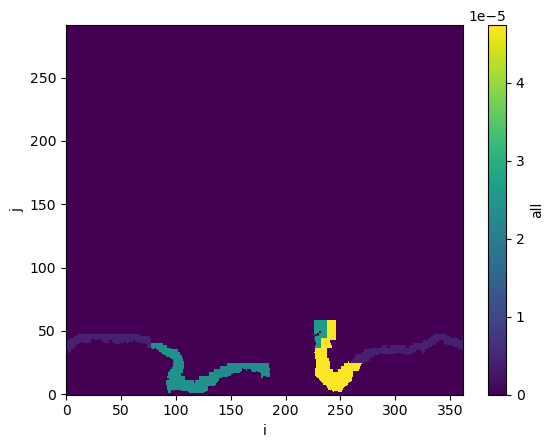

In [105]:
# Sum over the sectors
# Replace Nans with zeros before taking the sum of all regions
ds_calving_distribution = ds_calving_distribution.where(ds_calving_distribution>0,0)
ds_calving_distribution['all'] = ds_calving_distribution[sectors].to_array().sum("variable")
ds_calving_distribution['all'].plot.pcolormesh()

In [106]:
# BM per volume (in kg m-3 s-1)
# multiply with depth for each gridpoint
df_basal_melt_flux_per_volume = df_FWF_basal_melt*kg_per_Gt/spy/df_fwf_geom['basal melt volume']
df_basal_melt_flux_per_volume.values


array([[6.17889190985616e-08, 1.7499169001352036e-07,
        2.1379169875098968e-07, 1.238699223485635e-07,
        2.3024184873905568e-07, 1.23687318520981e-07]], dtype=object)

In [107]:
# Create dataset with basal melt distribution for each region
ds_basal_melt_distribution = xr.full_like(basal_melt_mask,np.nan)
for sector in sectors:
    ds_basal_melt_distribution[sector] = float(df_basal_melt_flux_per_volume[sector].values)*ds_depth.bmdepth.values*basal_melt_mask.basal_melt_mask.where(basal_melt_mask.basal_melt_mask==sector_dict[sector])

ds_basal_melt_distribution = ds_basal_melt_distribution.drop('basal_melt_mask')
ds_basal_melt_distribution

<xarray.Dataset>
Dimensions:    (j: 292, i: 362)
Coordinates:
    longitude  (j, i) float32 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
    latitude   (j, i) float32 -78.39 -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
Dimensions without coordinates: j, i
Data variables:
    eais       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    wedd       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    amun       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    ross       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    apen       (j, i) float64 nan nan nan nan nan nan ... nan nan nan nan nan

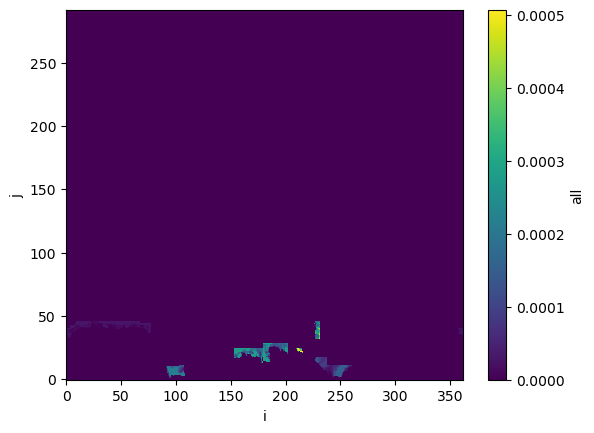

In [108]:
# Sum over the sectors
# Replace Nans with zeros before taking the sum of all regions
ds_basal_melt_distribution = ds_basal_melt_distribution.where(ds_basal_melt_distribution>0,0)
ds_basal_melt_distribution['all'] = ds_basal_melt_distribution[sectors].to_array().sum("variable")
ds_basal_melt_distribution['all'].plot.pcolormesh()